In [144]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/diseasesdataset/Training_base_cleaned.csv
/kaggle/input/diseasesdataset/Testing base.csv


In [145]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten
from keras.utils import to_categorical
from sklearn.metrics import precision_recall_fscore_support

In [146]:
train_df = pd.read_csv("/kaggle/input/diseasesdataset/Training_base_cleaned.csv")

In [147]:
print(train_df.head()) 

   anorexia  abdominal_pain  anaemia  abortions  acetone  aggression  \
0         0               0        0          0        0           0   
1         0               0        0          0        0           0   
2         0               0        0          0        0           0   
3         0               0        0          0        0           0   
4         0               0        0          0        0           0   

   arthrogyposis  ankylosis  anxiety  bellowing  ...  udder_heat  \
0              0          0        0          0  ...           0   
1              0          0        0          0  ...           0   
2              0          0        0          0  ...           0   
3              0          0        0          0  ...           1   
4              0          0        0          0  ...           1   

   udder_hardeness  udder_redness  udder_pain  unwillingness_to_move  ulcers  \
0                0              0           0                      0       0  

In [148]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Display basic info
print("Training Data Info:")
print(train_df.info())

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2004 entries, 0 to 2003
Data columns (total 94 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   anorexia                2004 non-null   int64 
 1   abdominal_pain          2004 non-null   int64 
 2   anaemia                 2004 non-null   int64 
 3   abortions               2004 non-null   int64 
 4   acetone                 2004 non-null   int64 
 5   aggression              2004 non-null   int64 
 6   arthrogyposis           2004 non-null   int64 
 7   ankylosis               2004 non-null   int64 
 8   anxiety                 2004 non-null   int64 
 9   bellowing               2004 non-null   int64 
 10  blood_loss              2004 non-null   int64 
 11  blood_poisoning         2004 non-null   int64 
 12  blisters                2004 non-null   int64 
 13  colic                   2004 non-null   int64 
 14  Condemnation_of_livers  2004 non-nul

In [149]:
### Handle Missing Values
train_df.fillna(train_df.median(numeric_only=True), inplace=True)

In [150]:
# Encode the target variable
label_encoder = LabelEncoder()
train_df['prognosis'] = label_encoder.fit_transform(train_df['prognosis'])

In [151]:
# Split the data into features and target
X = train_df.drop(columns=['prognosis'])
y = train_df['prognosis']

In [152]:
# Desired order of features
desired_order = ['anorexia', 'abdominal_pain', 'anaemia', 'abortions', 'acetone', 'aggression', 'arthrogyposis', 'ankylosis', 'anxiety', 'bellowing', 'blood_loss', 'colic', 'Condemnation_of_livers','coughing', 'discomfort', 'dysentery', 'dehydration', 'drooling', 'dull', 'emaciation', 'fever', 'facial_paralysis', 'frothing_of_mouth', 'frothing', 'gaseous_stomach', 'highly_diarrhoea', 'high_pulse_rate', 'high_temp', 'high_proportion', 'hyperaemia', 'hydrocephalus', 'isolation_from_herd', 'intermittent_fever', 'ketosis', 'loss_of_appetite', 'lameness', 'lack_of-coordination', 'lethargy', 'lacrimation', 'mild_diarrhoea', 'moaning', 'mucosal_lesions', 'milk_fever', 'nausea', 'nasel_discharges', 'oedema', 'pain']

In [153]:
# Ensure the feature order
X = X[desired_order]

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [154]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [155]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize SVM model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9501246882793017
SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        22
           1       0.87      0.76      0.81        17
           2       1.00      1.00      1.00         7
           3       0.89      0.89      0.89        19
           4       1.00      0.93      0.96        28
           5       1.00      0.67      0.80         3
           6       0.95      1.00      0.98        21
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00         9
          10       0.83      0.87      0.85        23
          11       1.00      0.82      0.90        11
          12       1.00      1.00      1.00        14
          13       1.00      1.00      1.00        23
          14       1.00      1.00      1.00        27
          15       1.00      1.00      1.00         7
          16       0

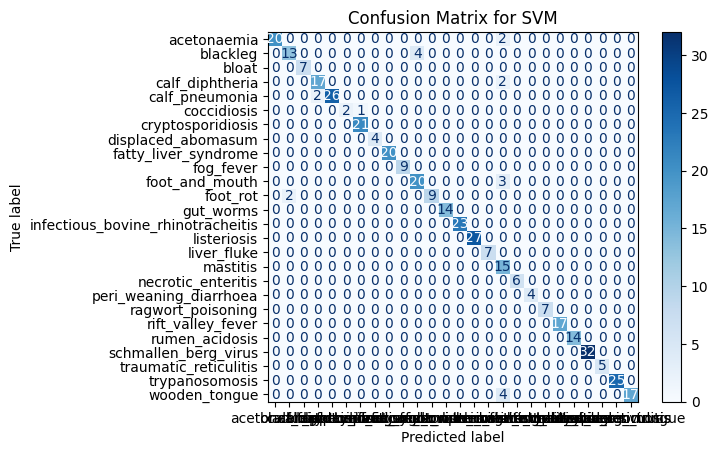

In [156]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=label_encoder.classes_)
disp_svm.plot(cmap="Blues")
plt.title("Confusion Matrix for SVM")
plt.show()

In [157]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9551122194513716
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        22
           1       0.81      1.00      0.89        17
           2       1.00      1.00      1.00         7
           3       0.89      0.89      0.89        19
           4       1.00      0.93      0.96        28
           5       1.00      0.67      0.80         3
           6       0.95      1.00      0.98        21
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00         9
          10       1.00      0.78      0.88        23
          11       1.00      0.82      0.90        11
          12       1.00      1.00      1.00        14
          13       1.00      1.00      1.00        23
          14       1.00      1.00      1.00        27
          15       1.00      1.00      1.00         7


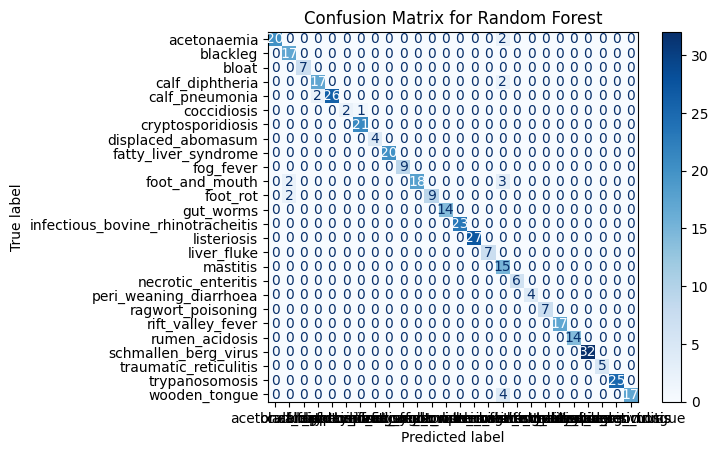

In [158]:
# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=label_encoder.classes_)
disp_rf.plot(cmap="Blues")
plt.title("Confusion Matrix for Random Forest")
plt.show()

In [159]:
from sklearn.metrics import accuracy_score

# Calculate accuracy for SVM
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {svm_accuracy:.4f}")

# Calculate accuracy for Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

SVM Accuracy: 0.9501
Random Forest Accuracy: 0.9551


In [160]:
# Convert target to categorical
y = to_categorical(y)

# Reshape the input data for CNN (add a channel dimension)
X = X.reshape(X.shape[0], X.shape[1], 1)

In [161]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [162]:
# Build the ANN model
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(y.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [163]:
# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3321 - loss: 2.6915 - val_accuracy: 0.7805 - val_loss: 0.8390
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8247 - loss: 0.6600 - val_accuracy: 0.8753 - val_loss: 0.4058
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8753 - loss: 0.3737 - val_accuracy: 0.8978 - val_loss: 0.2884
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9065 - loss: 0.2696 - val_accuracy: 0.9052 - val_loss: 0.2450
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9125 - loss: 0.2775 - val_accuracy: 0.8978 - val_loss: 0.2546
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9165 - loss: 0.2137 - val_accuracy: 0.9152 - val_loss: 0.2297
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9060 - loss: 0.2389 - val_accuracy: 0.9152 - val_loss: 0.2153
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9145 - loss: 0.2199 - val_accuracy: 0.9252 - val_loss:

In [164]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy:.2f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9004 - loss: 0.1759 
Test Accuracy: 0.92


In [165]:
# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(y_true, y_pred_classes, average='weighted')

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-score: {f1_score:.2f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Precision: 0.91
Recall: 0.92
F1-score: 0.91


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [166]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report

In [167]:
# Initialize the ANN model
ann_model = Sequential()

# Input Layer
ann_model.add(Dense(units=64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layers
ann_model.add(Dense(units=32, activation='relu'))
ann_model.add(Dense(units=16, activation='relu'))

# Output Layer (Softmax for multi-class classification)
ann_model.add(Dense(units=len(label_encoder.classes_), activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [168]:
#Compile the model
ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [169]:
# Train the model
history=ann_model.fit(X_train, y_train, epochs=70, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1296 - loss: 3.1451 - val_accuracy: 0.4364 - val_loss: 2.4859
Epoch 2/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5285 - loss: 2.1509 - val_accuracy: 0.6409 - val_loss: 1.4099
Epoch 3/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7239 - loss: 1.1206 - val_accuracy: 0.8703 - val_loss: 0.7106
Epoch 4/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9050 - loss: 0.5664 - val_accuracy: 0.9327 - val_loss: 0.3888
Epoch 5/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9415 - loss: 0.3254 - val_accuracy: 0.9327 - val_loss: 0.2791
Epoch 6/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9412 - loss: 0.2328 - val_accuracy: 0.9377 - val_loss: 0.2316
Epoch 7/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9377 - loss: 0.2136 - val_accuracy: 0.9426 - val_loss: 0.2049
Epoch 8/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9457 - loss: 0.1831 - val_accuracy: 0.9401 - val_loss:

In [170]:
from sklearn.metrics import accuracy_score, classification_report

# Convert one-hot encoded y_test to integer labels
y_test_int = y_test.argmax(axis=1)

# Make Predictions
y_pred_ann = ann_model.predict(X_test)
y_pred_ann_classes = y_pred_ann.argmax(axis=1)  # Convert predicted probabilities to class labels

# Calculate Accuracy
ann_accuracy = accuracy_score(y_test_int, y_pred_ann_classes)
print(f"ANN Accuracy: {ann_accuracy:.4f}")

# Print Classification Report
print("ANN Classification Report:\n", classification_report(y_test_int, y_pred_ann_classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
ANN Accuracy: 0.9476
ANN Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        22
           1       0.78      0.82      0.80        17
           2       1.00      1.00      1.00         7
           3       0.89      0.89      0.89        19
           4       1.00      0.93      0.96        28
           5       1.00      0.67      0.80         3
           6       0.95      1.00      0.98        21
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00         9
          10       0.86      0.78      0.82        23
          11       1.00      0.82      0.90        11
          12       1.00      1.00      1.00        14
          13       1.00      1.00      1.00        23
          14       1.00      1.00      1.00        27
          15       1.00      1.00      1.00    

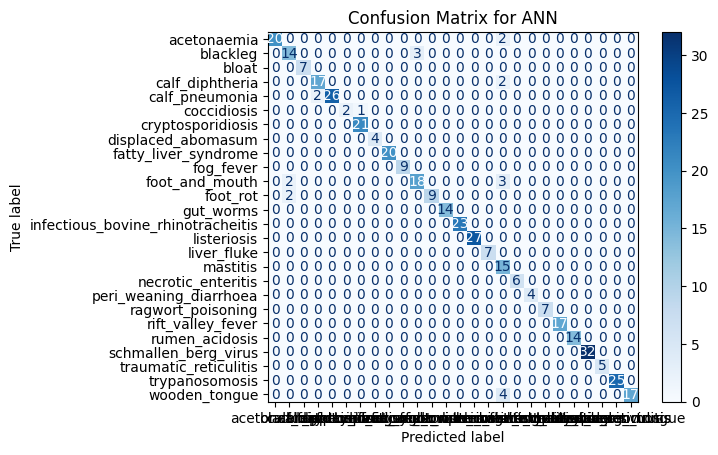

In [171]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Convert one-hot encoded y_test to integer labels
y_test_int = y_test.argmax(axis=1)

# Compute Confusion Matrix
cm_ann = confusion_matrix(y_test_int, y_pred_ann_classes)

# Display Confusion Matrix
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=label_encoder.classes_)
disp_ann.plot(cmap="Blues")

plt.title("Confusion Matrix for ANN")
plt.show()

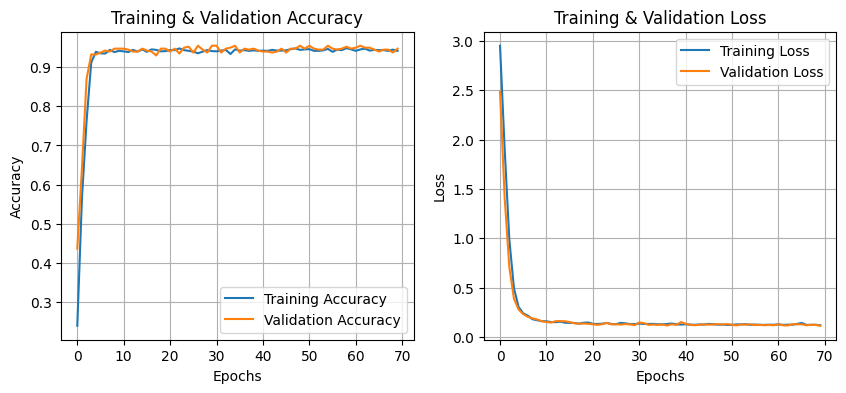

In [172]:
import matplotlib.pyplot as plt

# Extract training history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy Curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid()

# Plot Loss Curve
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [173]:
train_df = pd.read_csv("/kaggle/input/diseasesdataset/Training_base_cleaned.csv")
# Encode the target variable
label_encoder = LabelEncoder()
train_df['prognosis'] = label_encoder.fit_transform(train_df['prognosis'])
# Split the data into features and target
X = train_df.drop(columns=['prognosis'])
y = train_df['prognosis']

In [174]:
desired_order = ['anorexia', 'abdominal_pain', 'anaemia', 'abortions', 'acetone', 'aggression', 'arthrogyposis', 'ankylosis', 'anxiety', 'bellowing', 'blood_loss', 'colic', 'Condemnation_of_livers','coughing', 'discomfort', 'dysentery', 'dehydration', 'drooling', 'dull', 'emaciation', 'fever', 'facial_paralysis', 'frothing_of_mouth', 'frothing', 'gaseous_stomach', 'highly_diarrhoea', 'high_pulse_rate', 'high_temp', 'high_proportion', 'hyperaemia', 'hydrocephalus', 'isolation_from_herd', 'intermittent_fever', 'ketosis', 'loss_of_appetite', 'lameness', 'lack_of-coordination', 'lethargy', 'lacrimation', 'mild_diarrhoea', 'moaning', 'mucosal_lesions', 'milk_fever', 'nausea', 'nasel_discharges', 'oedema', 'pain']
# Ensure the feature order
X = X[desired_order]

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Naive Bayes Classifier Metrics:
Accuracy: 0.9277
Precision: 0.9448
Recall: 0.9277

🔹 Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        22
           1       0.70      0.82      0.76        17
           2       1.00      1.00      1.00         7
           3       0.89      0.89      0.89        19
           4       1.00      0.93      0.96        28
           5       0.60      1.00      0.75         3
           6       1.00      0.90      0.95        21
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00         9
          10       0.84      0.70      0.76        23
          11       1.00      0.82      0.90        11
          12       1.00      1.00      1.00        14
          13       1.00      1.00      1.00        23
          14       1.00      0.81      0.90        27
          15  

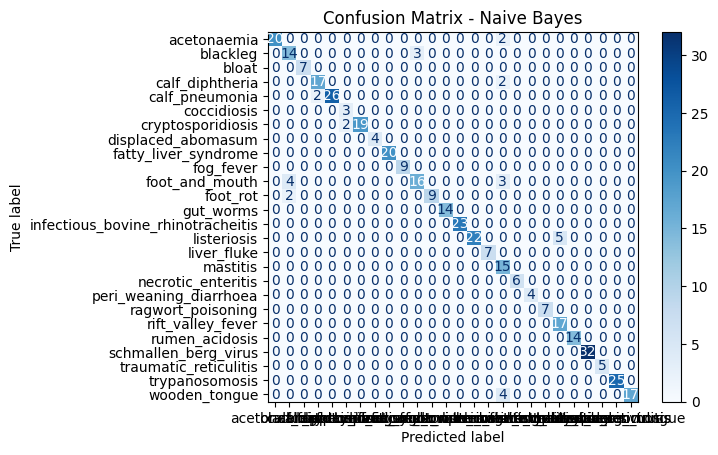

In [177]:
# Initialize and Train Naive Bayes Classifier
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make Predictions
nb_predictions = nb_model.predict(X_test)

# Print Metrics for Naive Bayes
print("Naive Bayes Classifier Metrics:")
print(f"Accuracy: {accuracy_score(y_test, nb_predictions):.4f}")
print(f"Precision: {precision_score(y_test, nb_predictions, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, nb_predictions, average='weighted'):.4f}")

# Print Classification Report
print("\n🔹 Naive Bayes Classification Report:\n", classification_report(y_test, nb_predictions))

# Plot Confusion Matrix
cm_nb = confusion_matrix(y_test, nb_predictions)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=label_encoder.classes_)
disp_nb.plot(cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()


📌 XGBoost Classifier Metrics:
Accuracy: 0.9476
Precision: 0.9592
Recall: 0.9476

🔹 XGBoost Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        22
           1       0.78      0.82      0.80        17
           2       1.00      1.00      1.00         7
           3       0.89      0.89      0.89        19
           4       1.00      0.93      0.96        28
           5       1.00      0.67      0.80         3
           6       0.95      1.00      0.98        21
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00         9
          10       0.86      0.78      0.82        23
          11       1.00      0.82      0.90        11
          12       1.00      1.00      1.00        14
          13       1.00      1.00      1.00        23
          14       1.00      1.00      1.00        27
          15       

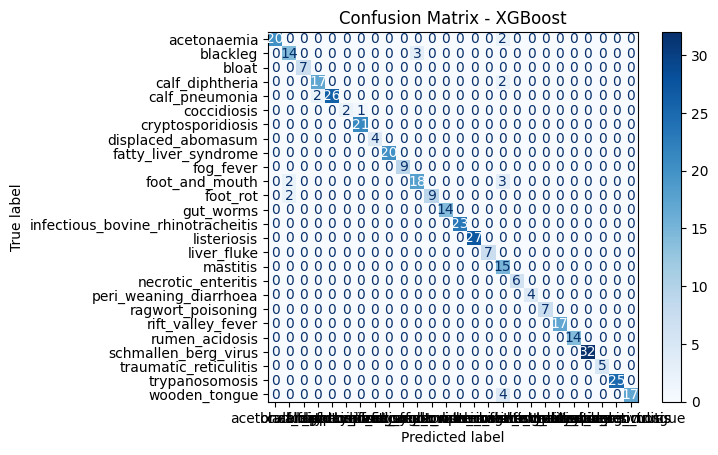

In [179]:
# Initialize and Train XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

# Make Predictions
xgb_predictions = xgb_model.predict(X_test)

# Print Metrics for XGBoost
print("\n📌 XGBoost Classifier Metrics:")
print(f"Accuracy: {accuracy_score(y_test, xgb_predictions):.4f}")
print(f"Precision: {precision_score(y_test, xgb_predictions, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, xgb_predictions, average='weighted'):.4f}")

# Print Classification Report
print("\n🔹 XGBoost Classification Report:\n", classification_report(y_test, xgb_predictions))

# Plot Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_predictions)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=label_encoder.classes_)
disp_xgb.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

<Figure size 2000x1000 with 0 Axes>

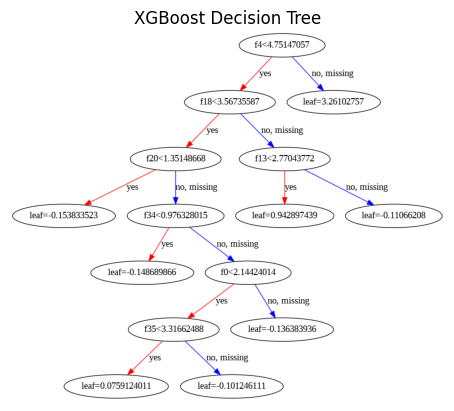

In [180]:
import matplotlib.pyplot as plt
from xgboost import plot_tree

# Set figure size
plt.figure(figsize=(20, 10))

# Plot the first tree of the XGBoost model
plot_tree(xgb_model, num_trees=0)  # num_trees=0 means the first tree
plt.title("XGBoost Decision Tree")
plt.show()


 K-Nearest Neighbors (KNN) Classifier Metrics:
Accuracy: 0.9302
Precision: 0.9472
Recall: 0.9302

🔹 KNN Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        22
           1       0.78      0.82      0.80        17
           2       1.00      1.00      1.00         7
           3       0.88      0.74      0.80        19
           4       1.00      0.93      0.96        28
           5       0.60      1.00      0.75         3
           6       1.00      0.90      0.95        21
           7       1.00      0.25      0.40         4
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00         9
          10       0.86      0.78      0.82        23
          11       1.00      0.82      0.90        11
          12       1.00      1.00      1.00        14
          13       1.00      1.00      1.00        23
          14       1.00      1.00      1.00        27
      

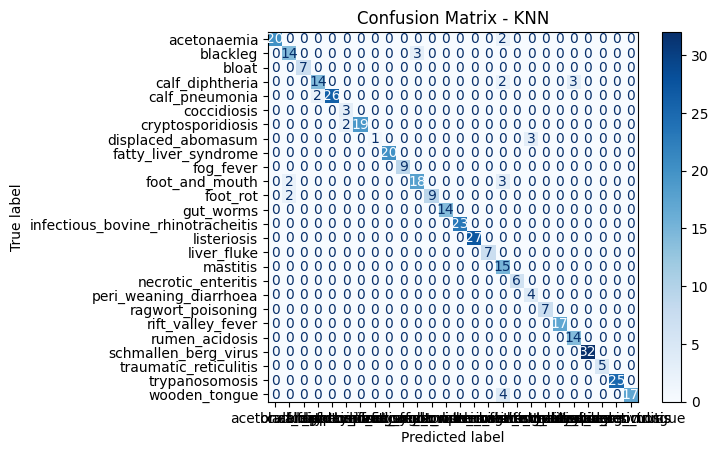

In [181]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and Train KNN Classifier (Choose k=5 as default)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train_labels)  # Use categorical labels (not one-hot encoded)

# Make Predictions
knn_predictions = knn_model.predict(X_test)

# Print Metrics for KNN
print("\n K-Nearest Neighbors (KNN) Classifier Metrics:")
print(f"Accuracy: {accuracy_score(y_test_labels, knn_predictions):.4f}")
print(f"Precision: {precision_score(y_test_labels, knn_predictions, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test_labels, knn_predictions, average='weighted'):.4f}")

# Print Classification Report
print("\n🔹 KNN Classification Report:\n", classification_report(y_test_labels, knn_predictions))

# Plot Confusion Matrix
cm_knn = confusion_matrix(y_test_labels, knn_predictions)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=label_encoder.classes_)
disp_knn.plot(cmap="Blues")
plt.title("Confusion Matrix - KNN")
plt.show()
